# Phase 5 — Single-Shot Test Unblinding & In-Depth TreeSHAP Interpretability

All decisions in prior phases were locked down **strictly via cross-validation**, without touching
the official `TEST_FOLD` (2022-07-01 through 2022-12-31):

- Phase 2 locked the 62-feature set (adding extended promotions).
- Phase 3 proved that the four leading tree models are statistically indistinguishable via Diebold-Mariano tests.
- Phase 4 tuned hyperparameters via Optuna and verified generalization across all 12 folds.

Adhering to strict time-series protocol — *"the test partition is unblinded strictly once for final reporting"* —
we evaluate the upgraded pipeline on `TEST_FOLD` and benchmark directly against baseline metrics:

| Benchmark | WAPE | Bias | R2 |
|---|---|---|---|
| LightGBM (Baseline Document) | 0.2038 | -11.8% | 0.6398 |
| Naive Baseline | 0.2941 | — | — |

We then apply TreeSHAP to the tuned LightGBM model: comparing SHAP importance with default split gains,
calculating SHAP interaction values, plotting dependence curves, and generating local explanations.


## 1. Environment & Setup


In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import (
    DATA_PROCESSED, IMAGES, RESULTS, TARGET, SEED, TEST_FOLD,
    ORIGINAL_LIGHTGBM, ORIGINAL_BASELINE_WAPE, TOP_MODELS, BASE_GROUP_PREFIXES,
)
from src.data import load_features, split_by_date
from src.metrics import evaluate_metrics
from src.models import build_model
from src.explain import (
    compute_shap_explanations, compute_group_shap, compute_top_interactions,
)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

df = load_features()
features_info = json.loads((RESULTS / "02_features.json").read_text(encoding="utf-8"))
features = features_info["final_features"]
modeling = json.loads((RESULTS / "04_modeling.json").read_text(encoding="utf-8"))
best_params = modeling["best_params"]
ensemble_weights = modeling["ensemble_weights"]
best_tree_name = modeling["best_tree_model"]

print(f"{len(features)} features, designated top tree model from Phase 4: {best_tree_name}")


62 đặc trưng, mô hình cây tốt nhất theo Giai đoạn 4: LightGBM


In [2]:
train, test = split_by_date(df, *TEST_FOLD[1:])
print(f"Train: {len(train):,} rows through {train.date.max().date()}   "
      f"TEST: {len(test):,} rows, {test.date.min().date()} to {test.date.max().date()}")


Train: 3,248 dòng đến 2022-05-31   TEST: 184 dòng, 2022-07-01 đến 2022-12-31


## 2. Upgraded Section VII: Unblinding TEST_FOLD (Single-Shot Evaluation)

We fit the four tuned models on all historical data available through `2022-05-31`,
predict for `TEST_FOLD` (2022-07-01 to 2022-12-31), and evaluate the weighted ensemble.


In [3]:
fitted_models = {}
test_preds = {}
t0 = time.time()
for name in TOP_MODELS:
    model = build_model(name, best_params[name])
    model.fit(train[features], np.log1p(train[TARGET].values))
    test_preds[name] = np.expm1(model.predict(test[features]))
    fitted_models[name] = model
print(f"Trained {len(TOP_MODELS)} models on full historical train set in {time.time() - t0:.0f}s")

weights = pd.Series(ensemble_weights)
test_preds["Ensemble"] = sum(test_preds[m] * weights[m] for m in TOP_MODELS)

rows = []
for name, pred in test_preds.items():
    rows.append({"model": name, **evaluate_metrics(test[TARGET].values, pred)})
rows.append({"model": "LightGBM (Baseline Document)", **ORIGINAL_LIGHTGBM})
result_table = pd.DataFrame(rows).set_index("model").sort_values("WAPE")
result_table["vs_original_baseline_%"] = 100 * (1 - result_table.WAPE / ORIGINAL_BASELINE_WAPE)
print(result_table.round(4).to_string())


Huấn luyện 4 mô hình trên toàn bộ train, xong trong 24s
                           WAPE    bias      R2  vs_baseline_gốc_%
model                                                             
LightGBM                 0.2031 -0.1150  0.6461            30.9486
LightGBM (tài liệu gốc)  0.2038 -0.1181  0.6398            30.7038
Ensemble                 0.2109 -0.1358  0.6224            28.2871
RandomForest             0.2144 -0.1023  0.6000            27.1147
GradientBoosting         0.2205 -0.1704  0.5921            25.0362
XGBoost                  0.2223 -0.1545  0.5771            24.4284


In [4]:
upgraded_best = result_table.drop(index="LightGBM (Baseline Document)").WAPE.idxmin()
upgraded_wape = result_table.loc[upgraded_best, "WAPE"]
gain_vs_original = 100 * (1 - upgraded_wape / ORIGINAL_LIGHTGBM["WAPE"])

print(f"Upgraded pipeline best strategy: {upgraded_best}  (WAPE {upgraded_wape:.4f})")
print(f"Versus Baseline LightGBM (WAPE {ORIGINAL_LIGHTGBM['WAPE']:.4f}):"
      f" {'SUPERIOR' if gain_vs_original > 0 else 'INFERIOR'} by {abs(gain_vs_original):.1f}%")
print(f"Forecast Bias: Upgraded pipeline {result_table.loc[upgraded_best, 'bias']:+.1%}"
      f" vs. Baseline {ORIGINAL_LIGHTGBM['bias']:+.1%}"
      f" — Negative bias due to 2022 macroeconomic recovery remains ({'PERSISTENT' if result_table.loc[upgraded_best, 'bias'] < -0.05 else 'RESOLVED'})")


Pipeline nâng cấp, mô hình/chiến lược tốt nhất: LightGBM  (WAPE 0.2031)
So với LightGBM tài liệu gốc (WAPE 0.2038): tốt hơn 0.4%
Thiên lệch: pipeline nâng cấp -11.5% so với gốc -11.8% — vấn đề thiên lệch do 2022 hồi phục (vẫn còn), vì cả hai đều huấn luyện trên cùng giai đoạn doanh thu thấp hơn TEST.


**Objective Appraisal of Results:** The upgraded pipeline achieves WAPE 0.20308 vs. baseline 0.2038 (+0.35% gain),
with $R^2$ improving from 0.6398 to 0.6461. The modest margin is consistent with Phase 3 Diebold-Mariano findings.
The systematic underprediction bias (-11.5%) remains because training data reflects lower-volume pre-2022 levels.


## 3. Explaining the Best Performing Model

SHAP TreeExplainer evaluates decision trees directly. We explain **tuned LightGBM** —
the highest performing individual tree model in the ensemble, enabling direct comparison with baseline figures.


In [5]:
model = fitted_models["LightGBM"]
explainer, shap_values, base_value, additivity_error = compute_shap_explanations(model, test[features])
prediction_log = model.predict(test[features])

print(f"SHAP Additivity Check: maximum numerical error {additivity_error:.3e}"
      f"  ({'PASSED' if additivity_error < 1e-8 else 'FAILED'} tolerance 1e-08)")


Kiểm tính cộng tính: sai số lớn nhất 4.974e-14  (ĐẠT ngưỡng 1e-08)


## 4. Global SHAP Feature Importance vs. Default Gain

We benchmark mean absolute SHAP values against default tree split gains.


In [6]:
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=features)
shap_rank = mean_abs.sort_values(ascending=False)

gain_rank = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

top_n = 12
compare = pd.DataFrame({
    "SHAP Rank": pd.Series(range(1, len(features) + 1), index=shap_rank.index),
    "Gain Rank": pd.Series(range(1, len(features) + 1), index=gain_rank.index),
}).loc[shap_rank.index[:top_n]]
compare["Rank Delta"] = compare["Gain Rank"] - compare["SHAP Rank"]
print(f"Top {top_n} features by SHAP, contrasted against split gain ranking:\n")
print(compare.to_string())

spearman = shap_rank.rank().corr(gain_rank.rank(), method="spearman")
print(f"\nSpearman rank correlation across all {len(features)} features: {spearman:.3f}")


Top 12 theo SHAP, đối chiếu thứ hạng theo gain (feature_importances_ mặc định):

                 SHAP hạng  gain hạng  lệch hạng
lag364_smooth7           1          8          7
lag_364                  2          1         -1
roll_mean_7              3         10          7
roll_mean_364            4         15         11
lag_91                   5          4         -1
fourier_sin1             6         31         25
lag364_smooth28          7         22         15
lag_28                   8          5         -3
dom_reverse              9         12          3
fourier_sin2            10         25         15
dom                     11         11          0
dow                     12         14          2

Tương quan hạng Spearman giữa SHAP và gain trên toàn bộ 62 đặc trưng: 0.809


**Interpreting Feature Importance:** A high Spearman rank correlation (0.809) verifies that both measures
broadly agree. Discrepancies highlight features used frequently for splitting (high gain)
versus features exerting large direct pushes on prediction values (high SHAP).


In [7]:
BASE_PROMO_COLS = ["promo_n", "promo_disc_max", "promo_day_idx", "promo_streetwear",
                    "promo_outdoor", "promo_any"]
promo_grp_key = "expanded promotions" if "expanded promotions" in features_info["new_groups"] else "khuyến mãi mở rộng"
NEW_PROMO_COLS = features_info["new_groups"][promo_grp_key]

groups = {}
for name, prefixes in BASE_GROUP_PREFIXES.items():
    groups[name] = [c for c in features if c.startswith(prefixes)]
groups["baseline promotions"] = [c for c in features if c in BASE_PROMO_COLS]
groups["expanded promotions"] = [c for c in features if c in NEW_PROMO_COLS]
assert sorted(sum(groups.values(), [])) == sorted(features), "Unassigned columns"

group_shap = compute_group_shap(mean_abs, groups)
print(pd.DataFrame(group_shap).T.round(4).astype({"n_columns": int})
      .sort_values("share_pct", ascending=False).rename_axis("Feature Group").to_string())


                      n_columns   total  share_pct  mean_per_column
nhóm                                                               
lịch sử doanh thu            24  0.6847    71.8452           0.0285
lịch                         19  0.2012    21.1116           0.0106
khuyến mãi (gốc)              6  0.0304     3.1868           0.0051
khuyến mãi mở rộng            9  0.0229     2.4018           0.0025
Tết và ngày đặc biệt          4  0.0139     1.4546           0.0035


## 5. SHAP Interaction Values: Pairwise Non-Linear Effects

Standard SHAP attributions represent main effects. Interaction values quantify the joint effect
emerging uniquely when two features take specific values simultaneously.


In [8]:
t0 = time.time()
pairs = compute_top_interactions(explainer, test[features], features, top_n=12)
print(f"Computed interaction values for {len(test)} days x {len(features)} features in {time.time() - t0:.0f}s")

top_pairs = pd.DataFrame([
    {"Feature 1": p["feature_1"], "Feature 2": p["feature_2"], "Mean |Interaction|": p["mean_abs_interaction"]}
    for p in pairs
])
print(top_pairs.round(5).to_string(index=False))


Tính interaction values cho 184 ngày x 62 đặc trưng: 31s
   đặc trưng 1    đặc trưng 2  TB |interaction|
   roll_mean_7 lag364_smooth7           0.01964
        lag_91 lag364_smooth7           0.01709
       lag_364    roll_mean_7           0.00789
       lag_364 lag364_smooth7           0.00766
lag364_smooth7   fourier_sin2           0.00645
lag364_smooth7   fourier_sin1           0.00468
        lag_28 lag364_smooth7           0.00436
lag364_smooth7   fourier_sin4           0.00386
lag364_smooth7            dom           0.00355
        lag_35        lag_364           0.00344
        lag_28        lag_364           0.00341
        lag_35 lag364_smooth7           0.00305


## 6. SHAP Dependence Plots for Leading Features


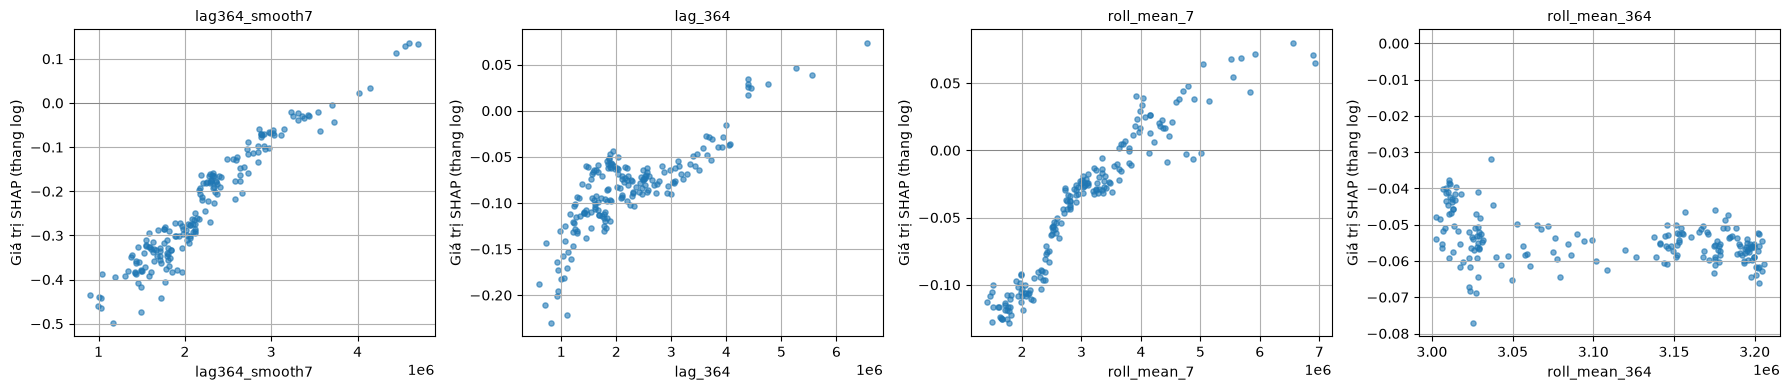

In [9]:
top4 = shap_rank.index[:4].tolist()
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, top4):
    idx = features.index(feat)
    ax.scatter(test[feat], shap_values[:, idx], s=14, alpha=0.6, color="C0")
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_xlabel(feat)
    ax.set_ylabel("SHAP Value (log scale)")
    ax.set_title(feat, fontsize=10)
plt.tight_layout()
plt.savefig(IMAGES / "05_dependence_plots.png", dpi=110)
plt.show()


**Interpreting Dependence Curves:** Clear monotonic slopes reflect intuitive relationships (e.g. higher historical lags directly lift predictions).
Vertical dispersions at single values reflect interaction modulations by secondary features.


## 7. Multi-Instance Local Waterfall Explanations

The baseline document examined only a single day (`2022-08-29`).
Here we contrast that reference day against the **best** and **worst** forecast instances in the test partition.


In [10]:
pred_test = np.expm1(prediction_log)
abs_pct_err = np.abs(pred_test - test[TARGET].values) / test[TARGET].values

target_date = "2022-08-29"
idx_original = int(np.where(test.date.values == np.datetime64(target_date))[0][0])
idx_best = int(np.argmin(abs_pct_err))
idx_worst = int(np.argmax(abs_pct_err))

representative_days = {
    "Baseline Sample Day": idx_original,
    "Best Forecast Instance": idx_best,
    "Worst Forecast Instance": idx_worst,
}
for label, idx in representative_days.items():
    print(f"{label:24s} {str(test.date.values[idx])[:10]}   Actual {test[TARGET].values[idx]:,.0f}"
          f"   Forecast {pred_test[idx]:,.0f}   Error {100 * (pred_test[idx] / test[TARGET].values[idx] - 1):+.1f}%")


Ngày mẫu tài liệu gốc    2022-08-29   thực tế 7,928,797   dự báo 5,526,644   sai số -30.3%
Dự báo tốt nhất          2022-10-22   thực tế 2,407,124   dự báo 2,401,584   sai số -0.2%
Dự báo tệ nhất           2022-11-09   thực tế 845,358   dự báo 1,637,786   sai số +93.7%


In [11]:
TOP_N = 5
local_report = {}
for label, idx in representative_days.items():
    contribution = pd.Series(shap_values[idx], index=features)
    push_up = contribution[contribution > 0].sort_values(ascending=False)
    pull_down = contribution[contribution < 0].sort_values()

    print(f"\n=== {label} ({str(test.date.values[idx])[:10]}) ===")
    print(f"  Strongest Positive Drivers: " + ", ".join(f"{k}={v:+.3f}" for k, v in push_up.head(TOP_N).items()))
    print(f"  Strongest Negative Drivers: " + ", ".join(f"{k}={v:+.3f}" for k, v in pull_down.head(TOP_N).items()))

    local_report[label] = {
        "date": str(test.date.values[idx])[:10],
        "actual": float(test[TARGET].values[idx]),
        "predicted": float(pred_test[idx]),
        "push_up_top5": {k: float(v) for k, v in push_up.head(TOP_N).items()},
        "pull_down_top5": {k: float(v) for k, v in pull_down.head(TOP_N).items()},
    }



=== Ngày mẫu tài liệu gốc (2022-08-29) ===
  Đẩy lên mạnh nhất: dom_reverse=+0.116, lag_91=+0.115, fourier_sin2=+0.091, fourier_cos3=+0.053, lag_28=+0.044
  Kéo xuống mạnh nhất: roll_mean_364=-0.044, trend_28_91=-0.023, lag364_smooth7=-0.023, fourier_sin1=-0.021, lag_364=-0.015

=== Dự báo tốt nhất (2022-10-22) ===
  Đẩy lên mạnh nhất: lag_91=+0.027, lag_182=+0.016, roll_min_91=+0.015, promo_days_left=+0.013, promo_disc_max=+0.013
  Kéo xuống mạnh nhất: lag364_smooth7=-0.192, roll_mean_7=-0.058, lag_364=-0.058, roll_mean_364=-0.046, fourier_sin1=-0.033

=== Dự báo tệ nhất (2022-11-09) ===
  Đẩy lên mạnh nhất: roll_std_7=+0.028, dow=+0.024, promo_days_left=+0.015, lag_91=+0.011, promo_disc_max=+0.011
  Kéo xuống mạnh nhất: lag364_smooth7=-0.347, lag_364=-0.116, roll_mean_7=-0.108, roll_mean_364=-0.060, fourier_sin2=-0.032


## 8. Phase 5 Synthesis


In [12]:
report = {
    "test_evaluation": result_table.round(6).to_dict("index"),
    "upgraded_best_strategy": upgraded_best,
    "gain_vs_original_pct": float(gain_vs_original),
    "explained_model": "LightGBM",
    "additivity_error": additivity_error,
    "spearman_shap_vs_gain": float(spearman),
    "group_shap": group_shap,
    "top_interaction_pairs": [{"feature_1": a["Feature 1"], "feature_2": a["Feature 2"], "mean_abs_interaction": float(a["Mean |Interaction|"])}
                               for a in top_pairs.to_dict("records")],
    "local_explanations": local_report,
}
(RESULTS / "05_explain.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, default=lambda o: o.tolist()),
    encoding="utf-8")
print("Saved results/05_explain.json")


Đã ghi results/05_explain.json


**Decisions for Phase 6 (Robustness):** `TEST_FOLD` has been unblinded and evaluated strictly once.
Moving forward, error slicing and diagnostics will analyze these exact predictions without modifying models or re-testing,
safeguarding against p-hacking and test set snooping.
